In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
import timeit
from scipy.sparse import csr_array,block_array,eye,coo_array
import os
import subprocess
loadstr=''
try:
    loadstr='module load %s &&'%(subprocess.check_output("module avail | grep cuda/", shell=True, text=True).split()[-1])
except:
    pass

Define coupling parameters for 2d CGLE

$$
\frac{\partial A}{\partial t} = A + (1+ib)\nabla^2 A - (1-ic)|A|^2 A,
$$

which we separate into real and imaginary parts $A=X+iY$ with


$$
\frac{\partial X}{\partial t} = X + \nabla^2 X - b \nabla^2 Y - (X^2+Y^2)X - c (X^2+Y^2)Y, \\
\frac{\partial Y}{\partial t} = Y + \nabla^2 Y + b \nabla^2 X - (X^2+Y^2)Y + c (X^2+Y^2)X.
$$

We can find the indices for the coupling terms with the help function with no filebase.

In [17]:
cmd='module load cuda && ./rdcu -t %f -d 0.1 -N %i,%i -L %f,%f -n 2 -v -D1 -h'%(T,Ns[0],Ns[1],Ls[0],Ls[1])
print(cmd)
os.system(cmd)

module load cuda && ./rdcu -t 10.000000 -d 0.1 -N 1024,1024 -L 100.000000,100.000000 -n 2 -v -D1 -h
usage:	rdcu [-hvSFR] [-n NFIELDS] [-N NUMS] [-L LENGTHS]
	[-c COUPLING] [-A AMPLITUDE] [-t TIME] [-d DT] [-s SEED] 
	[-D DENSITY] [-g GPU] [-r RTOL] [-a ATOL]  FILEBASE 

-h for help. Call with -n and -N to see Y indices. 
-v for verbose output, including progress 
-S for stiff system. Use the BDF method with finite differences instead of RK45 pseudospectral method. 
-F for fixed timestep 
-R to reload final state from FILEBASEfs.dat if possible
NFIELDS is the number of fields. Default 1
NUMS is number of grid points in each dimension (up to three), separated by commas (no spaces). Default 128
LENGTHS is domain length in each dimension (up to three), separated by commas (no spaces). Default 1.0
COUPLING is a list of coupling terms, separated by commas (no spaces). Default empty
	The first value is the term coefficent. 
	The second value is an integer specifying the field that the term ap

0

In [5]:
filebase='data/2dcgle'
Ns=[256,256]
N=Ns[0]*Ns[1]
Ls=[100.0,100.0]
T=10

b=2.0 
c=0.8
couplings=['1.0,0,0,1', '1.0,0,6,1', '1.0,0,12,1', '-%f,0,7,1'%(b), \
           '-%f,0,13,1'%(b), '-1.0,0,0,3', '-1.0,0,0,1,1,2', '1.0,1,1,1', \
           '1.0,1,7,1', '1.0,1,13,1', '%f,1,6,1'%(b),'%f,1,12,1'%(b), \
           '-1.0,1,0,2,1,1', '-1.0,1,1,3', '%f,1,0,3'%(c), '%f,1,0,1,1,2'%(c), \
           '-%f,0,0,2,1,1'%(c),'-%f,0,1,3'%(c)]

file=open('%scoupling.dat'%(filebase),'w')
for line in couplings:
    print(line,file=file)
file.close()

Explicit runge-kutta pseudospectral on the gpu. Save the final state as new initial condition to study behavior for nice initial conditions. 

module load cuda && ./rdcu -t 10.000000 -d 0.1 -N 256,256 -L 100.000000,100.000000 -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
t: 0.000000, h: 0.001000
1.000	2.341e+00	-2.168e-04	0.010712	924	
runtime: 2.344408
runtime: 2.344408



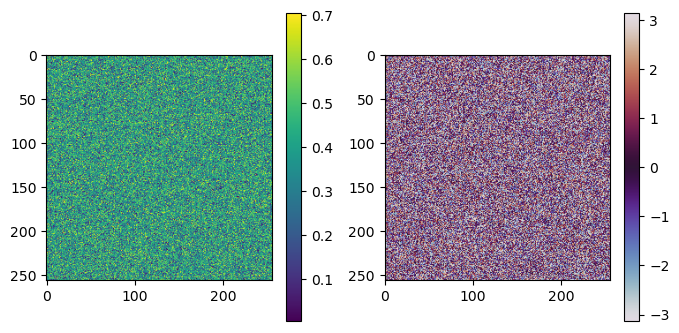

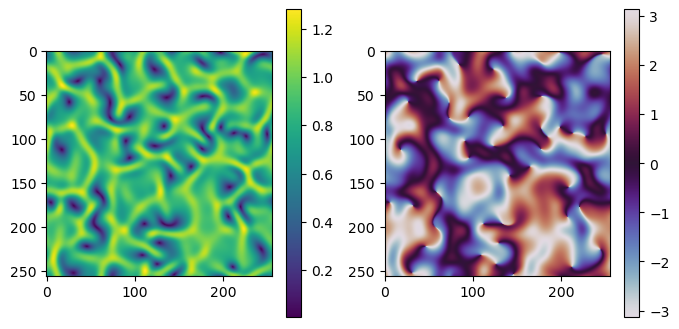

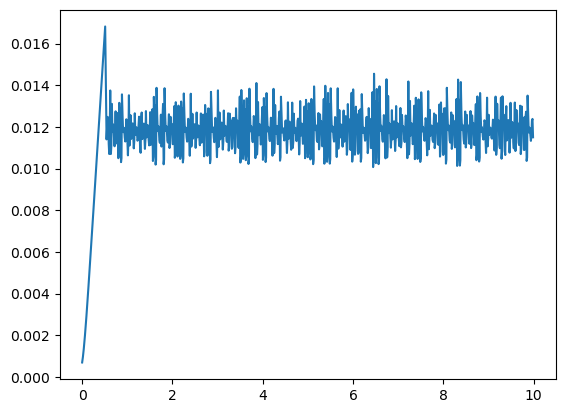

In [6]:
if os.path.exists('%sic.dat'%filebase):
    os.system('rm %sic.dat'%(filebase))

cmd='module load cuda && ./rdcu -t %f -d 0.1 -N %i,%i -L %f,%f -n 2 -v -D1 %s'%(T,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

U0=ys[-1].reshape(-1)
U0.tofile(filebase+'ic.dat')
for n in [0,len(ys)-1]:
    plt.subplots(1,2,figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow((ys[n][0]**2+ys[n][1]**2)**0.5)
    plt.colorbar()
    plt.subplot(1,2,2)
    plt.imshow(np.atan2(ys[n][1],ys[n][0]),vmin=-np.pi,vmax=np.pi,cmap='twilight')
    plt.colorbar()
    plt.show()
    
plt.plot(ts[:-1],np.diff(ts))

Explicit runge-kutta pseudospectral on the gpu again with nice initial condition.

module load cuda && ./rdcu -t 10.000000 -d 0.1,0.01 -N 256,256 -L 100.000000,100.000000 -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using initial conditions from file
t: 0.000000, h: 0.010000
1.000	2.362e+00	-7.521e-04	0.016380	842	
runtime: 2.365377
runtime: 2.365377



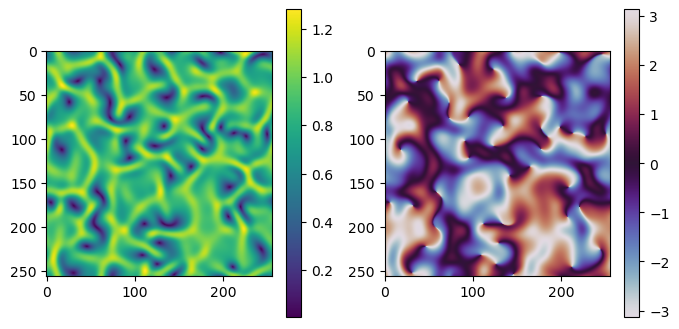

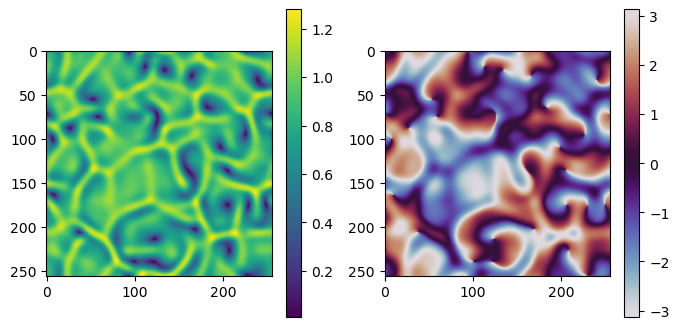

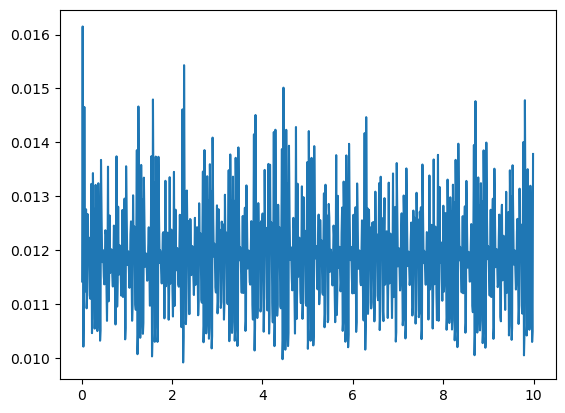

In [7]:
cmd='module load cuda && ./rdcu -t %f -d 0.1,0.01 -N %i,%i -L %f,%f -n 2 -v -D1 %s'%(T,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

for n in [0,len(ys)-1]:
    plt.subplots(1,2,figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow((ys[n][0]**2+ys[n][1]**2)**0.5)
    plt.colorbar()
    plt.subplot(1,2,2)
    plt.imshow(np.atan2(ys[n][1],ys[n][0]),vmin=-np.pi,vmax=np.pi,cmap='twilight')
    plt.colorbar()
    plt.show()
    
plt.plot(ts[:-1],np.diff(ts))

implicit BDF with finite differences on gpu with the same initial condition. Note the first few timesteps are small before the BDF stabilizes.

module load cuda && ./rdcu -t 10.000000 -d 0.1,0.01 -N 256,256 -L 100.000000,100.000000 -n 2 -v -S -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using initial conditions from file
t: 0.000000, h: 0.010000
1.003	3.727e+00	-1.126e-02	0.035938	288	
runtime: 3.741897
runtime: 3.741897



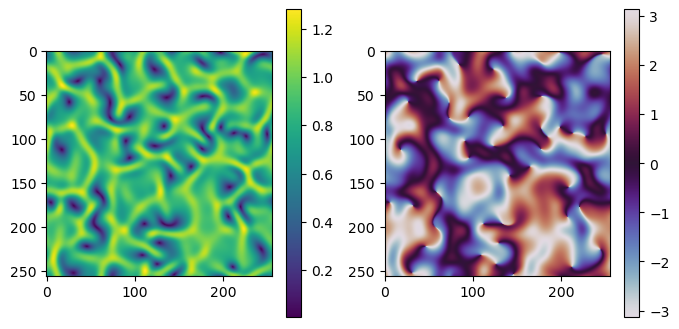

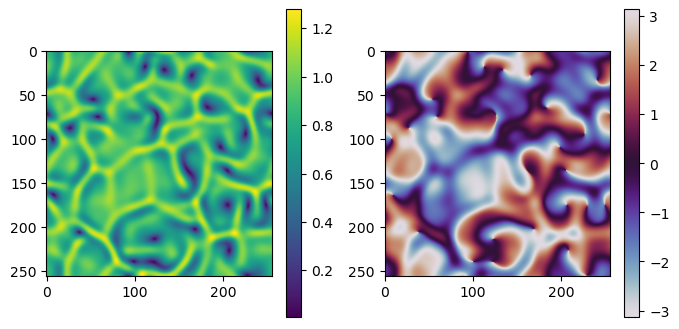

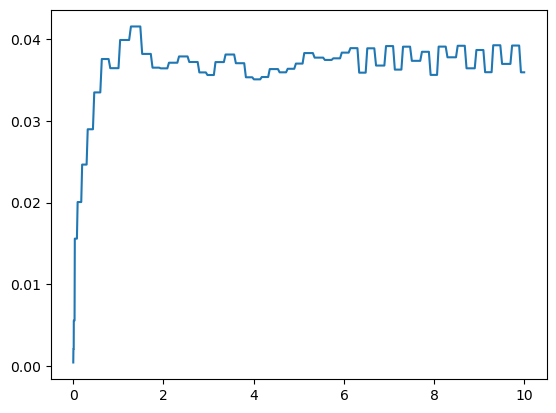

In [8]:
cmd='module load cuda && ./rdcu -t %f -d 0.1,0.01 -N %i,%i -L %f,%f -n 2 -v -S -D1 %s'%(T,Ns[0],Ns[1],Ls[0],Ls[1], filebase)
print(cmd)
os.system(cmd)

file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

for n in [0,len(ys)-1]:
    plt.subplots(1,2,figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow((ys[n][0]**2+ys[n][1]**2)**0.5)
    plt.colorbar()
    plt.subplot(1,2,2)
    plt.imshow(np.atan2(ys[n][1],ys[n][0]),vmin=-np.pi,vmax=np.pi,cmap='twilight')
    plt.colorbar()
    plt.show()
    
plt.plot(ts[:-1],np.diff(ts))

Explicit runge-kutta pseudospectral on the cpu. The GPU results are almost identical and much faster, and performance benefits increase with increasing Ns.

runtime:  14.857090815901756


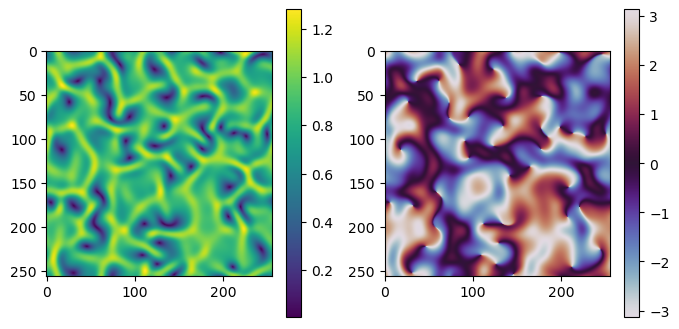

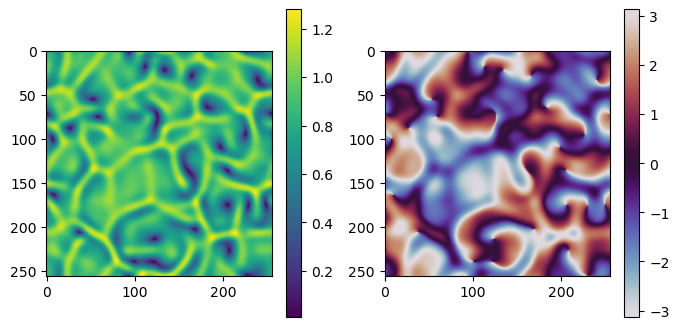

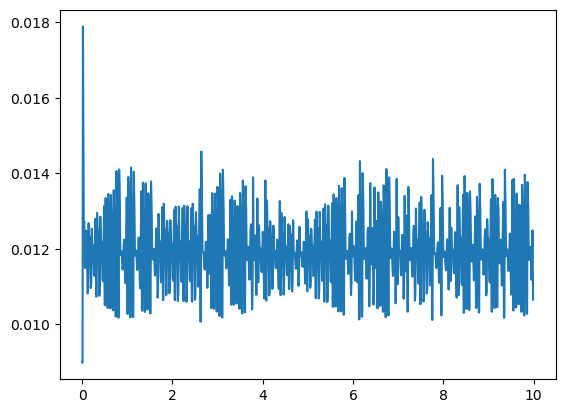

In [9]:
def lap(y,Ls,Ns):
    yfft=np.fft.fftn(y)
    ret=-np.fft.fftfreq(Ns[0],Ls[0]/(2*np.pi*Ns[0])).reshape((Ns[0],1))**2*yfft
    ret=ret-np.fft.fftfreq(Ns[1],Ls[1]/(2*np.pi*Ns[1])).reshape((1,Ns[1]))**2*yfft
    return np.fft.ifftn(ret)

def cgle(t, U, b, c, Ls, Ns):
    N=Ns[0]*Ns[1]
    X=U[:N].reshape(Ns)
    Y=U[N:].reshape(Ns)
    A=X+1j*Y
    lapA=lap(A,Ls,Ns)
    lapX=np.real(lapA)
    lapY=np.imag(lapA)
    retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    ret=np.zeros(U.shape)
    ret[:N]=retX.reshape(-1)
    ret[N:]=retY.reshape(-1)
    return ret

start=timeit.default_timer()
sol1=solve_ivp(cgle,[0,T],U0,args=[b,c,Ls,Ns],method='RK45',rtol=1E-8,atol=1E-8,first_step=0.03)
stop=timeit.default_timer()
print("runtime: ", stop-start, flush=True)

ys=sol1.y.reshape([2]+Ns+[-1]).transpose(3,0,1,2)
ts=sol1.t

for n in [0,len(ys)-1]:
    plt.subplots(1,2,figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow((ys[n][0]**2+ys[n][1]**2)**0.5)
    plt.colorbar()
    plt.subplot(1,2,2)
    plt.imshow(np.atan2(ys[n][1],ys[n][0]),vmin=-np.pi,vmax=np.pi,cmap='twilight')
    plt.colorbar()
    plt.show()

plt.plot(ts[:-1],np.diff(ts))

implicit BDF with finite differences on cpu. Again the GPU results are almost identical and are comparatively even faster. The sparse LU solver from scipy performs poorly compared to cudss and scales very poorly with increasing Ns.

runtime:  107.39517373777926


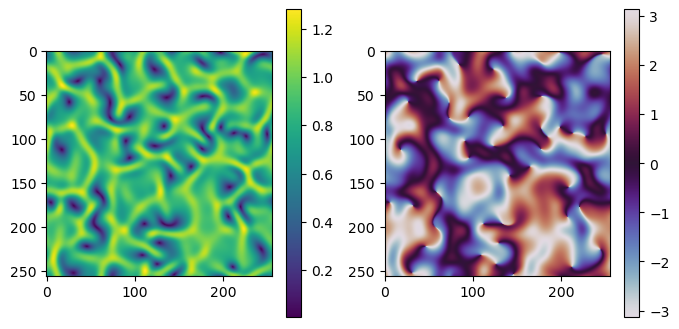

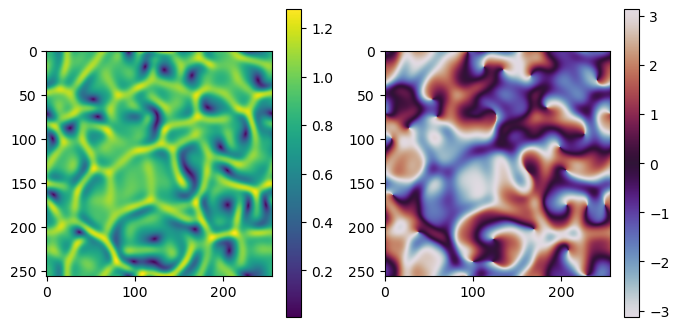

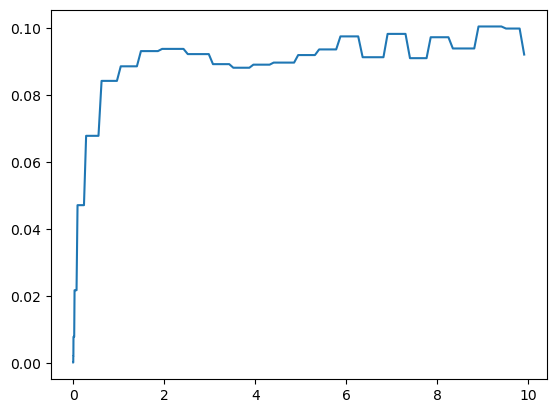

In [10]:
def lap(y,Ls,Ns):
    return (np.roll(y,1,axis=0)+np.roll(y,-1,axis=0)-2*y)/(Ls[0]/Ns[0])**2+(np.roll(y,1,axis=1)+np.roll(y,-1,axis=1)-2*y)/(Ls[1]/Ns[1])**2

def cgle(t, U, b, c, Ls, Ns, I, JI):
    N=Ns[0]*Ns[1]
    X=U[:N].reshape(Ns)
    Y=U[N:].reshape(Ns)
    A=X+1j*Y
    lapA=lap(A,Ls,Ns)
    lapX=np.real(lapA)
    lapY=np.imag(lapA)
    retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    ret=np.zeros(U.shape)
    ret[:N]=retX.reshape(-1)
    ret[N:]=retY.reshape(-1)
    return ret

def jac(t, U, b, c, Ls, Ns, I, JI):
    N=Ns[0]*Ns[1]
    X=U[:N]
    Y=U[N:]
#     retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retXX=I+JI-(2*X*I)*(X+c*Y)-(X**2+Y**2)*I
    retXY=-b*JI-(2*Y*I)*(X+c*Y)-(X**2+Y**2)*I*c
#     retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    retYX=b*JI-(2*X*I)*(Y-c*X)+(X**2+Y**2)*I*c
    retYY=I+JI-(2*Y*I)*(Y-c*X)-(X**2+Y**2)*I
    return block_array([[retXX,retYX],[retXY, retYY]]).T


I=csr_array(eye(N))
coords=I.reshape(Ns+Ns).coords
data=I.reshape(Ns+Ns).data
Ip0=coo_array((data,(coords[0],coords[1],np.roll(coords[2],Ns[0]),coords[3])),Ns+Ns).reshape(N,N)
Ip1=coo_array((data,(coords[0],coords[1],coords[2],np.roll(coords[3],1))),Ns+Ns).reshape(N,N)
Im0=coo_array((data,(coords[0],coords[1],np.roll(coords[2],-Ns[0]),coords[3])),Ns+Ns).reshape(N,N)
Im1=coo_array((data,(coords[0],coords[1],coords[2],np.roll(coords[3],-1))),Ns+Ns).reshape(N,N)
JI=(Ip0+Im0-2*I)/(Ls[0]/Ns[0])**2+(Ip1+Im1-2*I)/(Ls[1]/Ns[1])**2

start=timeit.default_timer()
sol1=solve_ivp(cgle,[0,T],U0,args=[b,c,Ls,Ns,I,JI],method='BDF',jac=jac,rtol=1E-6,atol=1E-6)
stop=timeit.default_timer()
print("runtime: ", stop-start, flush=True)

ys=sol1.y.reshape([2]+Ns+[-1]).transpose(3,0,1,2)
ts=sol1.t

for n in [0,len(ys)-1]:
    plt.subplots(1,2,figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow((ys[n][0]**2+ys[n][1]**2)**0.5)
    plt.colorbar()
    plt.subplot(1,2,2)
    plt.imshow(np.atan2(ys[n][1],ys[n][0]),vmin=-np.pi,vmax=np.pi,cmap='twilight')
    plt.colorbar()
    plt.show()

plt.plot(ts[:-1],np.diff(ts))

Note that BDF takes larger steps that RK45. As the number of mesh points Ns increases, the system gets stiffer and RK45 takes increasingly smaller steps while BDF does not. The sparse LU scales well enough that BDF outperforms RK45 for large Ns.  Illustrate with a very large system size.

module load cuda && ./rdcu -t 10.000000 -d 0.1 -N 1024,1024 -L 100.000000,100.000000 -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
t: 0.000000, h: 0.001000
1.000	1.473e+02	-3.074e-03	0.000741	13614	
runtime: 147.338843
runtime: 147.338843



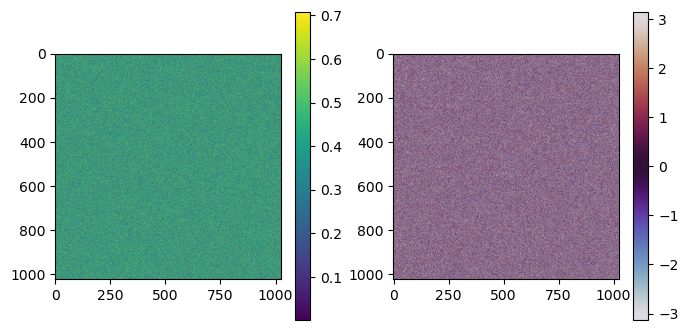

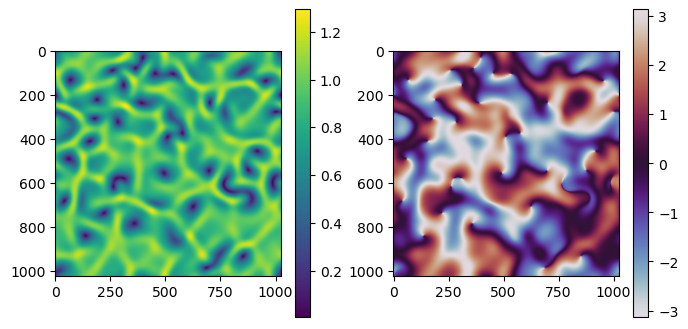

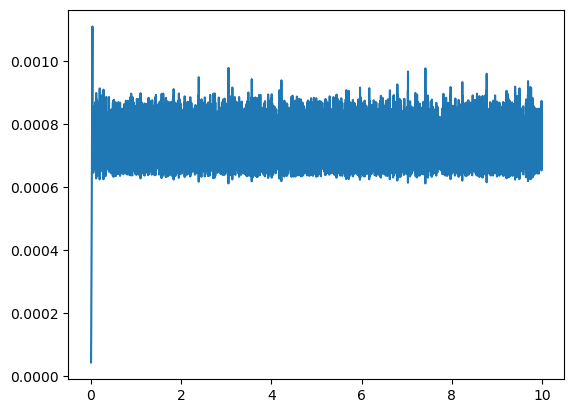

In [11]:
Ns=[1024,1024]

if os.path.exists('%sic.dat'%filebase):
    os.system('rm %sic.dat'%(filebase))

cmd='module load cuda && ./rdcu -t %f -d 0.1 -N %i,%i -L %f,%f -n 2 -v -D1 %s'%(T,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

for n in [0,len(ys)-1]:
    plt.subplots(1,2,figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow((ys[n][0]**2+ys[n][1]**2)**0.5)
    plt.colorbar()
    plt.subplot(1,2,2)
    plt.imshow(np.atan2(ys[n][1],ys[n][0]),vmin=-np.pi,vmax=np.pi,cmap='twilight')
    plt.colorbar()
    plt.show()
    
plt.plot(ts[:-1],np.diff(ts))

module load cuda && ./rdcu -t 10.000000 -d 0.1 -N 1024,1024 -L 100.000000,100.000000 -S -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
t: 0.000000, h: 0.001000
1.003	5.664e+01	-1.485e-01	0.035411	779	
runtime: 56.932980
runtime: 56.932980



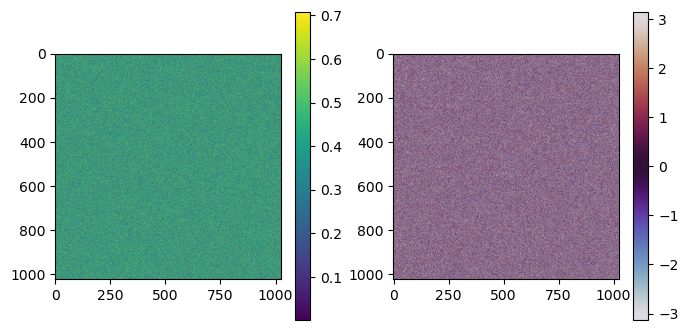

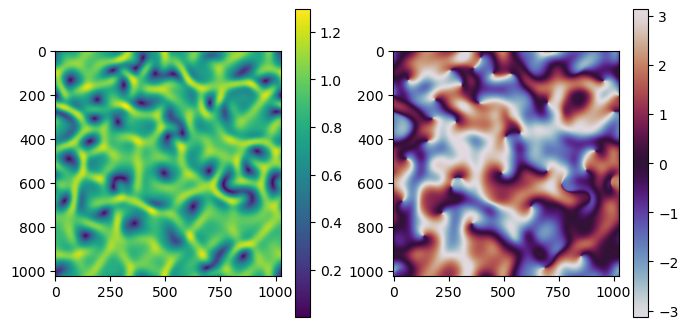

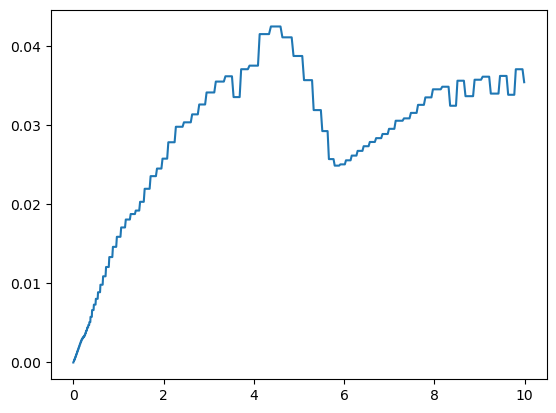

In [12]:
Ns=[1024,1024]

if os.path.exists('%sic.dat'%filebase):
    os.system('rm %sic.dat'%(filebase))

cmd='module load cuda && ./rdcu -t %f -d 0.1 -N %i,%i -L %f,%f -S -n 2 -v -D1 %s'%(T,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

for n in [0,len(ys)-1]:
    plt.subplots(1,2,figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow((ys[n][0]**2+ys[n][1]**2)**0.5)
    plt.colorbar()
    plt.subplot(1,2,2)
    plt.imshow(np.atan2(ys[n][1],ys[n][0]),vmin=-np.pi,vmax=np.pi,cmap='twilight')
    plt.colorbar()
    plt.show()
    
plt.plot(ts[:-1],np.diff(ts))

For both integration methods, you can reload saved final states and continue as well

module load cuda && ./rdcu -t 20.000000 -d 0.1 -N 1024,1024 -L 100.000000,100.000000 -R -S -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Reloading final conditions from file
Restarting at t=10.026377 with h=0.035411
t: 10.026377, h: 0.035411
1.002	4.333e+01	-9.825e-02	0.035654	273	
runtime: 44.194894
runtime: 44.194894



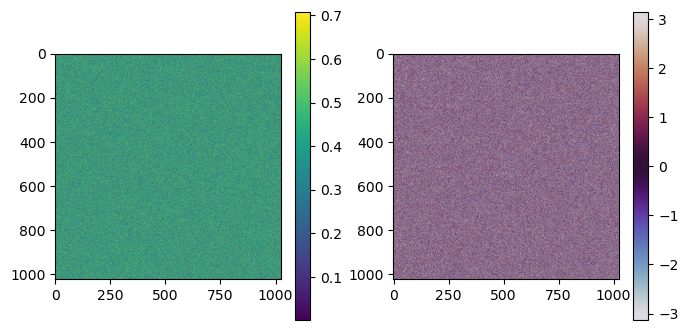

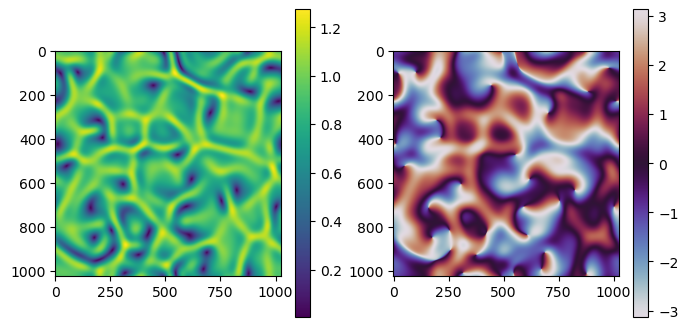

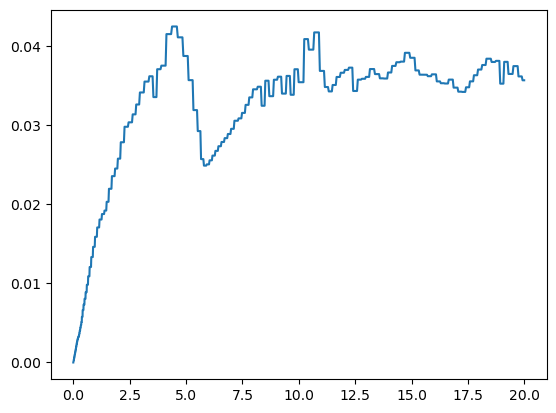

In [14]:
cmd='module load cuda && ./rdcu -t %f -d 0.1 -N %i,%i -L %f,%f -R -S -n 2 -v -D1 %s'%(2*T,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

for n in [0,len(ys)-1]:
    plt.subplots(1,2,figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow((ys[n][0]**2+ys[n][1]**2)**0.5)
    plt.colorbar()
    plt.subplot(1,2,2)
    plt.imshow(np.atan2(ys[n][1],ys[n][0]),vmin=-np.pi,vmax=np.pi,cmap='twilight')
    plt.colorbar()
    plt.show()
    
plt.plot(ts[:-1],np.diff(ts))